# El perceptrón

## Objetivos

- Abordar uno de los algoritmos más simples de aprendizaje, el perceptron
- Implementarlo en python

## El modelo de neurona

Uno de los primero trabajos sobre el modelado simplificado de neuronas para diseño de modelos de inteligencia artificial se remonta a los trabajos de *McCulloch* y *Pitts*, en 1943. A este modelo se le conoce como neurona de **McCulloch-Pitts (MCP)**^[1]. 

El modelo de *McCulloch* y *Pitts* describe una celula como una compuerta lógica simple con una salida binaria; multiples señales llegan a las dendrítas (entradas) y son integradas en el cuerpo de la celula. Después, si el acumulado excede cierto **umbral**, la señal de salida será activada por el axón.

*Frank Rosenblatt* publicará, pocos años despues, el concepto de **perceptrón**[^2] basado en el modelo de neurona de *MCP*. Con este trabajo Rosenblatt propone un algoritmo que aprenderá los **pesos optimos**, que al ser multiplicados por cierto **vector de entrada**, hará predicciones adecuadas sobre cuando una neurona se activará (o sea será un 1 a la salida) o no (o sea un 0 a la salida).

[^1]: *A Logical Calculus of the Ideas Immanent in Nervous Activity by W. S. McCulloch and W. Pitts, Bulletin of Mathematical Biophysics, 5(4): 115-133, 1943*
[^2]: *The Perceptron: A Perceiving and Recognizing Automaton by F. Rosenblatt, Cornell Aeronautical Laboratory, 1957*

<center><img src="img/neuron_model.png" width=600></center>

> Neurona humana que procesa señales químicas y electricas. Tomado de *ML con Pytorch y Scikit-Learn, Raschka et. al*

### ❓ Para que tipo de modelos de *ML* sirve lo propuesto por *MCP* y *Rosenblatt*

### Definición de neurona artificial

- Las neuronas arificiales en el contexto de la clasificación binaria pueden ser definidas como una función de decisión $\sigma(z)$ que tomará la combinación líneal de cierta entrada, $x$, y un vector de pesos correspondiente, $w$, donde $z$ es la entrada de la red:

$$
z=w_1x_1+w_2x_2+...+w_nx_n
$$

- Si la entrada de un ejemplo particular $x^{(i)}$, es mayor que cierto umbrál, $\theta$, la predicción será la clase `1`, en caso contrario la clase `0`. Esto es que la función $\sigma(z)$ estará definida como una función escalón:


$$
\sigma(z) = \begin{cases}
    1 & z \geq \theta\\
    0 & \text{otro caso}
\end{cases}
$$

Para simplificar la implementación podemos mover el umbrial de la ecuación:

$$
\begin{align}
z \geq \theta\\
z-\theta \geq 0
\end{align}
$$

Con esto definimos el *bias* $b=\theta$ y lo integramos a la entrada de la red:

$$
\begin{align}
z'=w_1x_1+w_2x_2+...+w_nx_n+b\\
z'=\textbf{w}^T\textbf{x}+b
\end{align}
$$

Con la introducción del *bias* podemos redefinir la función de decisión:

$$
\sigma(z') = \begin{cases}
    1 & z' \geq 0\\
    0 & \text{otro caso}
\end{cases}
$$

<center><img src="img/decision_func.png" width=600></center>

> Umbral de la función que produce una separación líneal. Tomado de *ML con Pytorch y Scikit-Learn, Raschka et. al*

### Reglas de aprendizaje para el perceptrón

1. inicializa los pesos y el *bias* en `0` o a un valor random pequeño
2. Para cada ejemplo de entrenamiento $x^{(i)}$:
    - Computa el valor de salida $\hat{y}^{(i)}$
    - Actualizar los pesos y el *bias*

Las salidas predichas por la función de decisión actualizarán los pesos y el *bias* en el vector de pesos $\textbf{w}$
$$
\begin{align}
    w_j = w_j + \Delta w_j\\
    b = b + \Delta b
\end{align}
$$

dónde los valores actualizados ($\Delta$) se computan de la siguiente forma:

$$
\begin{align}
    \Delta w_j = \eta(y^{i} -  \hat{y}^{(i)})x^{(i)}_j\\
    \Delta b = \eta(y^{i} -  \hat{y}^{(i)})
\end{align}
$$

$\eta$ es la **tasa de aprendizaje** (constante que va entre 0.0 y 1.0), $y^{i}$ es la etiqueta de la clase real del $ith$ ejemplo de entrenamiento y $\hat{y}^{(i)}$ es la clase predicha.

#### Ejemplo

### Línealidad

La convergencía del perceptron está garantizada solo si existe una línea que separé ambos conjutnos de clases.

<center><img src="img/separated.png" width=600></center>

#### ❓ Qué pasaría con el perceptrón si no son linealmente ceparables

Si no son línealmente separables nunca dejaría de actualizar los pesos. Para evitar esto podemos añadir un parámetro máximo de iteraciones (**epochs**) p un umbral de clasificaciones erroneas permitidas. 

<center><img src="img/perceptron.png" width=700></center>

## Implementación

### Vectorización 

In [27]:
x0, x1, x2 = 1., 2., 3.
bias, w1, w2 = 0.1, 0.3, 0.5

x = [x0, x1, x2]
w = [bias, w1, w2]

In [29]:
timeit?

Docstring:
Time execution of a Python statement or expression

**Usage, in line mode**::

  %timeit [-n<N> -r<R> [-t|-c] -q -p<P> [-o|-v <V>]] statement

**or in cell mode**::

  %%timeit [-n<N> -r<R> [-t|-c] -q -p<P> [-o|-v <V>]] setup_code
  code
  code...

Time execution of a Python statement or expression using the timeit
module.  This function can be used both as a line and cell magic:

- In line mode you can time a single-line statement (though multiple
  ones can be chained with using semicolons).

- In cell mode, the statement in the first line is used as setup code
  (executed but not timed) and the body of the cell is timed.  The cell
  body has access to any variables created in the setup code.

Options:

-n<N>
  Execute the given statement N times in a loop. If N is not
  provided, N is determined so as to get sufficient accuracy.

-r<R>
  Number of repeats R, each consisting of N loops, and take the
  average result.
  Default: 7

-t
  Use ``time.time`` to measure the time

In [33]:
%%time
z = 0.
for i in range(len(x)):
    z += x[i] * w[i]

CPU times: user 8 μs, sys: 0 ns, total: 8 μs
Wall time: 11.7 μs


In [34]:
%%time
z = sum(x_i * w_i for x_i, w_i in zip(x, w))

CPU times: user 16 μs, sys: 0 ns, total: 16 μs
Wall time: 23.4 μs


In [31]:
import numpy as np

In [36]:
%%time
x_vec, w_vec = np.array(x), np.array(w)
z = (x_vec).dot(w_vec)

CPU times: user 51 μs, sys: 1e+03 ns, total: 52 μs
Wall time: 57.9 μs


In [38]:
%time
np.dot(x_vec, w_vec)

CPU times: user 6 μs, sys: 1 μs, total: 7 μs
Wall time: 11.7 μs


np.float64(2.2)

### Perceptron en `python`

In [37]:
import numpy as np
from numpy.random import RandomState

In [137]:
class Perceptron:
    """Clasificador Perceptron

    Parameters
    ------------
    eta : float
      Learning rate (entre 0.0 y 1.0)
    epochs : int
      Numero de pasos para entrenamiento.
    random_state : int
      Semilla para el generador de número aleatorios para
      inicialización de pesos
    
    Attributes
    -----------
    w: 1d-array
      Pesos despues del entrenamiento
    b : Scalar
      Bias unit despues del entrenamiento
    errors : list
      Número de clases incorrectamente clasificadas para cada epoch
    """

    def __init__(self, eta=0.01, epochs=100, random_state=42, verbose=False):
        self.eta = eta
        self.epochs = epochs
        self.random_state = random_state
        self.errors = []
        self.verbose = verbose
        
    def fit(self, X: np.array, y: np.array):
        random_gen = RandomState(self.random_state)
        # Generamos números pequeños de una distribución normal
        # con std=0.01 y media=0.0
        self.w = random_gen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        # El bias será inicializado en 0
        self.b = np.float64(1.)
        for _ in range(self.epochs):
            error = 0
            for x_i, target in zip(X, y):
                # Obtenemos z
                update = self.eta * (target - self.predict(x_i))
                # Actualizamos los pesos
                self.w += update * x_i
                # Actualizamos el bias
                self.b += update
                error += int(update != 0.0)
                if self.verbose:
                    print(f"EPOCH: {_} loss: {error} | w={self.w} | b={self.b}")        
            self.errors.append(error)
        return self

    def forward(self, X: np.array):
        return np.dot(X, self.w) + self.b

    def predict(self, X: np.array):
        # Función de decisión z >= 0; 1, 0 en otro caso
        return np.where(self.forward(X) >= 0.0, 1, 0)

### Ejercicio: Aplica el perceptron al conjunto de datos Iris

- El perceptrón que implementamos esta restringido a dos dimensiones y clasificación binaria
  - Utiliza las características `sepal length` y `petal length`
  - Utiliza las clases `Setosa` y `Versicolor`
- Realiza un plot de exploración con las features y clases.
    - Verifica que tengamos datos linealmente separables
- Realiza un plot del error acumulado
    - Verifica que disminuya

In [3]:
# Tu código chido aquí 🧙🏼‍♂️

In [138]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)

In [139]:
df = iris.frame
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')

In [140]:
df = df[(df["target"] == 0) | (df["target"] == 1)] 

In [141]:
len(df)

100

In [142]:
len(df)

100

In [143]:
y = df["target"]
Y = y.to_numpy()

In [144]:
x = df[["sepal length (cm)", "petal length (cm)"]]
X = x.values

In [145]:
len(np.where(Y == 0)[0])

50

In [146]:
len(x)

100

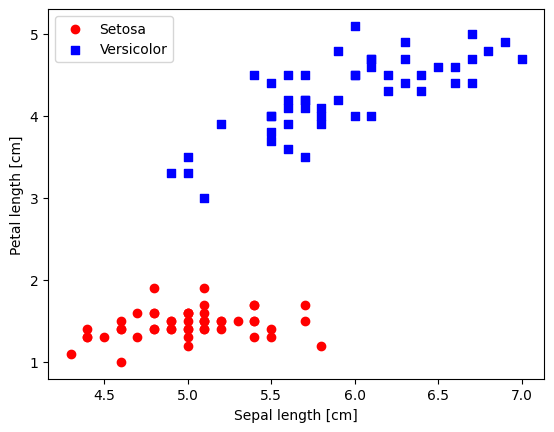

In [147]:
import matplotlib.pyplot as plt
plt.scatter(X[:50, 0], X[:50, 1], color='red', marker='o', label='Setosa')
plt.scatter(X[50:100, 0], X[50:100, 1], color='blue', marker='s', label='Versicolor')
plt.xlabel('Sepal length [cm]')
plt.ylabel('Petal length [cm]')
plt.legend(loc='upper left')
plt.show()

In [151]:
p = Perceptron(eta=0.1, epochs=10, random_state=42)
p.fit(X,y)

In [152]:
p.errors

[2, 2, 3, 3, 2, 3, 1, 0, 0, 0]

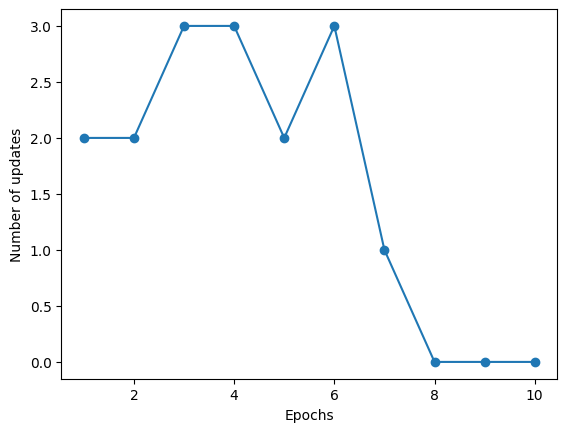

In [153]:
plt.plot(range(1, len(p.errors) + 1), p.errors, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Number of updates')
plt.show()

## Revisemos la práctica

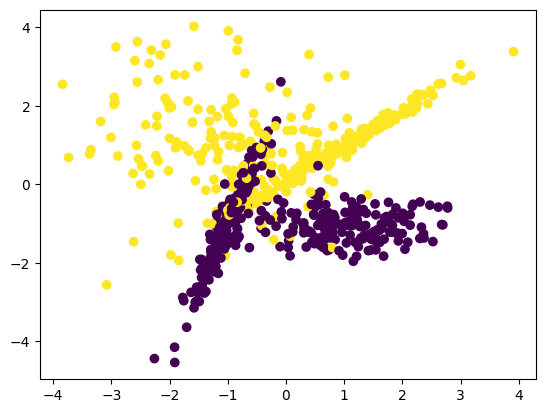

In [154]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

x, y = make_classification(
    n_samples=1000, n_features=2, n_redundant=0, n_informative=2, random_state=42
)
x_train, x_eval, y_train, y_eval = train_test_split(x, y, test_size=0.3)

plt.scatter(x_train[:, 0], x_train[:, 1], c=y_train)
plt.show()

In [155]:
class Node:
    """Un nodo"""
    def __call__(self, x):
        return self.forward(x)

    def __str__(self):
        return str(self.out)

In [159]:
class Foo:
    def __init__(self, a):
        self.a = a

    def __call__(self):
        print("called", self.a * 10)

In [160]:
foo_instance = Foo(8)
foo_instance()

called 80
